# FFNN with TD-IDF

This notebook trains a FFNN to classify a news article into one of 5 bias labels using TF-IDF representations of each news article.

## Import 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from skorch import NeuralNetClassifier

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [2]:
# Load preprocessed data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

## Weighted FFNN Model

In [3]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train['cleaned_text']).toarray()
X_test = vectorizer.transform(test['cleaned_text']).toarray()

In [4]:
# FFNN Model
# We chose a 3 layer model as LSTM has 3 gates
class FFNN(nn.Module):
    def __init__(self, input_dim, dropout, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)

In [5]:
# Class weights
class_counts = np.bincount(y_train)
class_counts = torch.tensor(class_counts, dtype=torch.float)
weights = 1. / class_counts
weights = weights / weights.sum()

Weight normalization is used here to maintain a consistent overall scale. This prevents disproportionately large loss values for rare classes, which could lead to unstable or overly aggressive gradient updates. By normalizing the weights to sum to 1, the training process remains numerically stable while still emphasizing underrepresented classes.

## Hyperparameter Tuning

In [ ]:
# Wrap model for skorch
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from torch.optim.lr_scheduler import ReduceLROnPlateau

net = NeuralNetClassifier(
    module=FFNN,
    module__input_dim=input_dim,
    module__hidden_dim=256,
    module__output_dim=output_dim,
    module__dropout=0.2,
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss(weight=weights),
    lr=1e-3,
    batch_size=32,  # Matching LSTM batch size
    max_epochs=20,  # Matching LSTM max epochs
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(policy=ReduceLROnPlateau,
                   monitor='valid_f1',  
                   factor=0.5,
                   patience=5,
                   verbose=True),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False),
    ]
)

We fixed the TD-IDF parameters to the same hyper parameters obtained when tuning the decision tree for a fairer comparison between the models

In [7]:
# Grid search parameters
param_grid = {
    'module__hidden_dim': [128, 256, 512],
    'module__dropout': [0.1, 0.3, 0.5],
    'lr': [0.0005, 0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_epochs': [5, 10]
}

In [8]:
grid = GridSearchCV(net, param_grid, scoring='f1_weighted', cv=3, verbose=1)
grid.fit(X_train.astype(np.float32), y_train)

print("Best parameters found:")
print(grid.best_params_)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.2318      0.1674        1.6077       0.2275      0.1547        1.5967  0.0005  0.6447
      2       0.6609      0.6238        1.5505       0.6052      0.5638        1.5258  0.0005  0.4047
      3       0.8433      0.8205        1.2398       0.6395      0.6083        1.3031  0.0005  0.3996
      4       0.9582      0.9576        0.6391       0.6266      0.6157        1.1169  0.0005  0.3997
      5       0.9914      0.9914        0.2351       0.6352      0.6296        1.0921  0.0005  0.3994


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.2586      0.2433        1.6094       0.5064      0.3934        1.6009  0.0005  0.3936
      2       0.5944      0.5004        1.5545       0.5966      0.5405        1.5532  0.0005  0.4000
      3       0.8326      0.8231        1.3072       0.6438      0.6312        1.4038  0.0005  0.4086
      4       0.9539      0.9531        0.7406       0.6266      0.6232        1.2506  0.0005  0.3999
      5       0.9828      0.9828        0.2761       0.6352      0.6356        1.2494  0.0005  0.4128


...

  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.3315      0.3182        1.6224       0.3433      0.3575        1.5334  0.0100  0.2579
      2       0.6223      0.6282        1.0949       0.6309      0.6258        1.5182  0.0100  0.3127
      3       0.8659      0.8673        0.3684       0.5365      0.5517        1.5662  0.0100  0.3326
      4       0.9506      0.9508        0.1400       0.5923      0.6007        1.9004  0.0100  0.3623
      5       0.9689      0.9690        0.0978       0.6009      0.5959        2.4370  0.0100  0.3567
      6       0.9850      0.9850        0.0353       0.6309      0.6023        3.3320  0.0100  0.2676
Stopping since valid_f1 has not improved in the last 5 epochs.


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.3208      0.3198        1.5504       0.3077      0.3158        1.4212  0.0100  0.3107
      2       0.6921      0.7053        0.8287       0.5256      0.5553        1.6740  0.0100  0.3419
      3       0.9206      0.9219        0.2421       0.6325      0.6277        2.0943  0.0100  0.3509
      4       0.9624      0.9626        0.1562       0.5855      0.6022        1.8990  0.0100  0.3008
      5       0.9657      0.9659        0.0721       0.6624      0.6160        4.2149  0.0100  0.3411
      6       0.9850      0.9851        0.0380       0.7051      0.6850        2.8482  0.0100  0.3040
      7       0.9839      0.9840        0.0665       0.6795      0.6680        2.5179  0.0100  0.2959
      8       0.9925      0.9925        0.0334       0.6795      0.6693        2.4

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.3863      0.3551        1.5733       0.6371      0.5800        1.4560  0.0010  1.6519
      2       0.7432      0.7313        0.9715       0.6514      0.6620        1.1892  0.0010  1.6144
      3       0.9227      0.9240        0.2898       0.6943      0.6922        1.4064  0.0010  1.5710
      4       0.9850      0.9850        0.0655       0.6429      0.6368        1.5597  0.0010  1.5735
      5       0.9943      0.9943        0.0278       0.6657      0.6737        1.6976  0.0010  1.5947
Best parameters found:
{'batch_size': 16, 'lr': 0.001, 'max_epochs': 5, 'module__dropout': 0.5, 'module__hidden_dim': 512}


Available metrics: dict_keys(['batches', 'epoch', 'train_batch_count', 'valid_batch_count', 'dur', 'train_loss', 'train_loss_best', 'valid_loss', 'valid_loss_best', 'valid_acc', 'valid_acc_best', 'train_f1', 'train_f1_best', 'train_acc', 'train_acc_best', 'valid_f1', 'valid_f1_best', 'event_lr'])


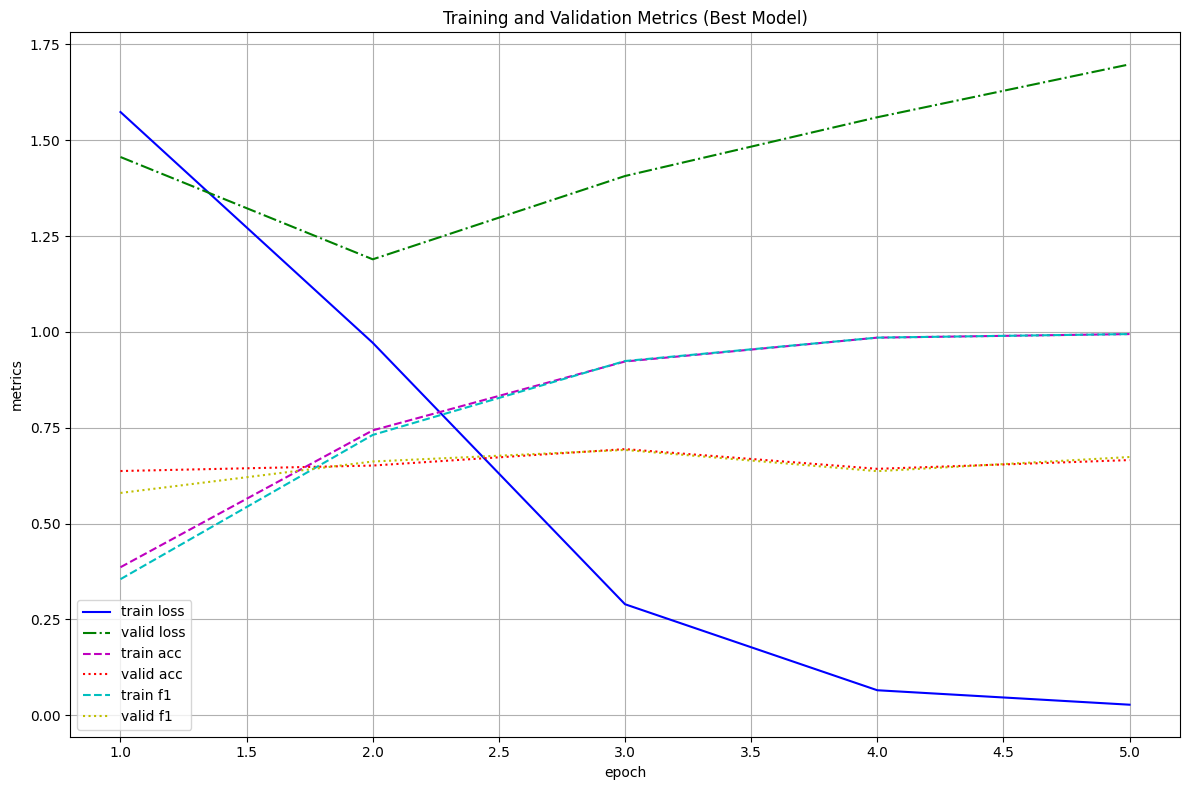

In [9]:
best_model = grid.best_estimator_

if hasattr(best_model, 'history_') and best_model.history_ is not None:
    # Print available metrics for debugging
    print("Available metrics:", best_model.history_[0].keys())
    
    epochs = list(range(1, len(best_model.history_) + 1))
    
    # Extract available metrics
    train_loss = [h.get('train_loss', None) for h in best_model.history_]
    valid_loss = [h.get('valid_loss', None) for h in best_model.history_]
    train_acc = [h.get('train_acc', None) for h in best_model.history_]
    valid_acc = [h.get('valid_acc', None) for h in best_model.history_]
    train_f1 = [h.get('train_f1', None) for h in best_model.history_]
    valid_f1 = [h.get('valid_f1', None) for h in best_model.history_]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.grid(True)
    
    # Plot metrics that exist
    if not all(x is None for x in train_loss):
        plt.plot(epochs, train_loss, 'b-', label='train loss')
    if not all(x is None for x in valid_loss):
        plt.plot(epochs, valid_loss, 'g-.', label='valid loss')
    if not all(x is None for x in train_acc):
        plt.plot(epochs, train_acc, 'm--', label='train acc')
    if not all(x is None for x in valid_acc):
        plt.plot(epochs, valid_acc, 'r:', label='valid acc')
    if not all(x is None for x in train_f1):
        plt.plot(epochs, train_f1, 'c--', label='train f1')
    if not all(x is None for x in valid_f1):
        plt.plot(epochs, valid_f1, 'y:', label='valid f1')
    
    plt.xlabel('epoch')
    plt.ylabel('metrics')
    plt.title('Training and Validation Metrics (Best Model)')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
else:
    print("Model history not found in the best estimator.")
    
    # If you want to see what's available
    if hasattr(best_model, 'history_'):
        print("History exists but might be empty or formatted differently.")
    else:
        print("No history_ attribute found on the best model.")

## Evaluation

Given the loss profile over epochs for the model, we elect to stop training at epoch 2 to prevent overfitting. 

In [15]:
# Create a new model with the same hyperparameters but train only for 2 epochs
from copy import deepcopy

# Get best parameters
best_params = grid.best_params_

# Rebuild model manually
best_model_epoch2 = NeuralNetClassifier(
    module=FFNN,  
    module__input_dim=input_dim,
    module__hidden_dim=best_params['module__hidden_dim'],  
    module__output_dim=output_dim,
    module__dropout=best_params['module__dropout'],
    optimizer=optim.Adam,     
    criterion=nn.CrossEntropyLoss(weight=weights),    
    lr=best_params['lr'],
    batch_size=best_params['batch_size'],
    max_epochs=2,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(policy=ReduceLROnPlateau,
                   monitor='valid_f1',  
                   factor=0.5,
                   patience=5,
                   verbose=True),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False),
    ]    
)
# Fit again
best_model_epoch2.fit(X_train.astype(np.float32), y_train)

# Evaluate
preds = best_model_epoch2.predict(X_test.astype(np.float32))
probs = best_model_epoch2.predict_proba(X_test.astype(np.float32))

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
report = classification_report(y_test, preds, target_names=label_encoder.classes_, digits=4)

print(f"FFNN Accuracy (epoch 2): {acc * 100:.2f}%")
print(f"FFNN Macro F1-score (epoch 2): {f1:.4f}")
print("\nClassification Report (epoch 2):\n", report)

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.3691      0.3417        1.5816       0.6400      0.5939        1.4864  0.0010  1.4996
      2       0.7275      0.7197        0.9971       0.6400      0.6496        1.2347  0.0010  1.5530
FFNN Accuracy (epoch 2): 66.13%
FFNN Macro F1-score (epoch 2): 0.5709

Classification Report (epoch 2):
               precision    recall  f1-score   support

      center     0.8947    0.4146    0.5667        41
   lean left     0.4306    0.5082    0.4662        61
  lean right     0.3659    0.4054    0.3846        37
        left     0.8104    0.7703    0.7898       222
       right     0.5851    0.7237    0.6471        76

    accuracy                         0.6613       437
   macro avg     0.6173    0.5644    0.5709       437
weighted avg     0.6885    0.6613    0.6646       437

In [20]:
# # Evaluate best model
# best_model = grid.best_estimator_
# preds = best_model.predict(X_test.astype(np.float32))
# probs = best_model.predict_proba(X_test.astype(np.float32))

# acc = accuracy_score(y_test, preds)
# f1 = f1_score(y_test, preds, average='macro')
# report = classification_report(y_test, preds, target_names=label_encoder.classes_, digits=4)

# print(f"FFNN Accuracy: {acc * 100:.2f}%")
# print(f"FFNN Macro F1-score: {f1:.4f}")
# print("\nClassification Report:\n", report)

#### Classification Report Commentary

The FFNN outperforms all decision tree variants in overall accuracy, reaching 72.54% accuracy. Macro F1-score (0.6109) has also improved and is the highest so far.

- The model performs very well on the majority class:
  - Left: F1 = 0.8327
- It also performs reasonably well on a minority class:
  - Right: F1 = 0.6849
- Other minority classes remain problematic:
	- Center: F1 = 0.5574 
	- Lean left: F1 = 0.5862
	- Lean right: F1 = 0.3934 (lowest overall)

This shows that while the FFNN is effective overall, it continues to struggle with detecting minority class instances, especially lean right. This is likely due to the effects of the imbalanced dataset. 

### Confusion Matrices

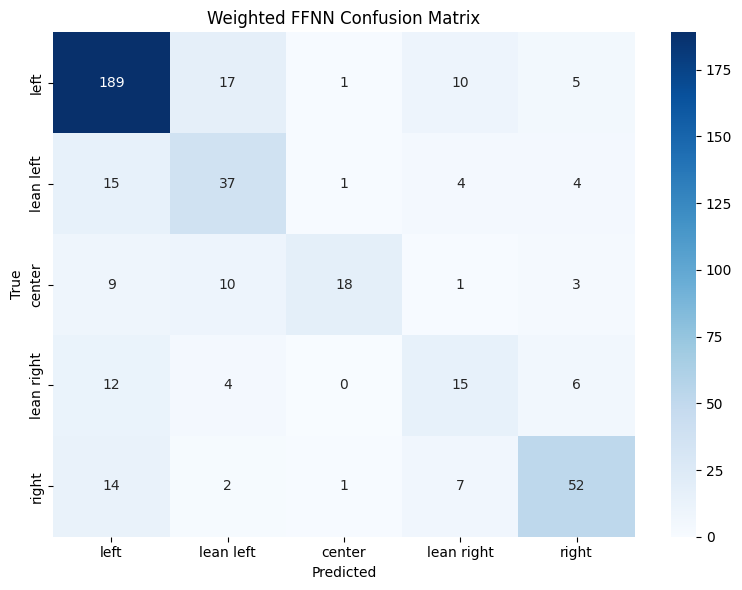

In [17]:
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

cm = confusion_matrix(y_test, preds, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Weighted FFNN Confusion Matrix')
plt.tight_layout()
plt.show()

- The FFNN performs well on the "left" and "right" classes, with 204 and 50 correct predictions respectively, showing strong class identification on the extremes.
- There is still moderate confusion between neighboring classes like "lean left" and "left", and between "lean right" and "right", indicating room for improvement in boundary refinement.
- Compared to decision trees, the FFNN appears more balanced overall but struggles slightly with nuanced central categories like "lean right" and "center".

### ROC-AUC

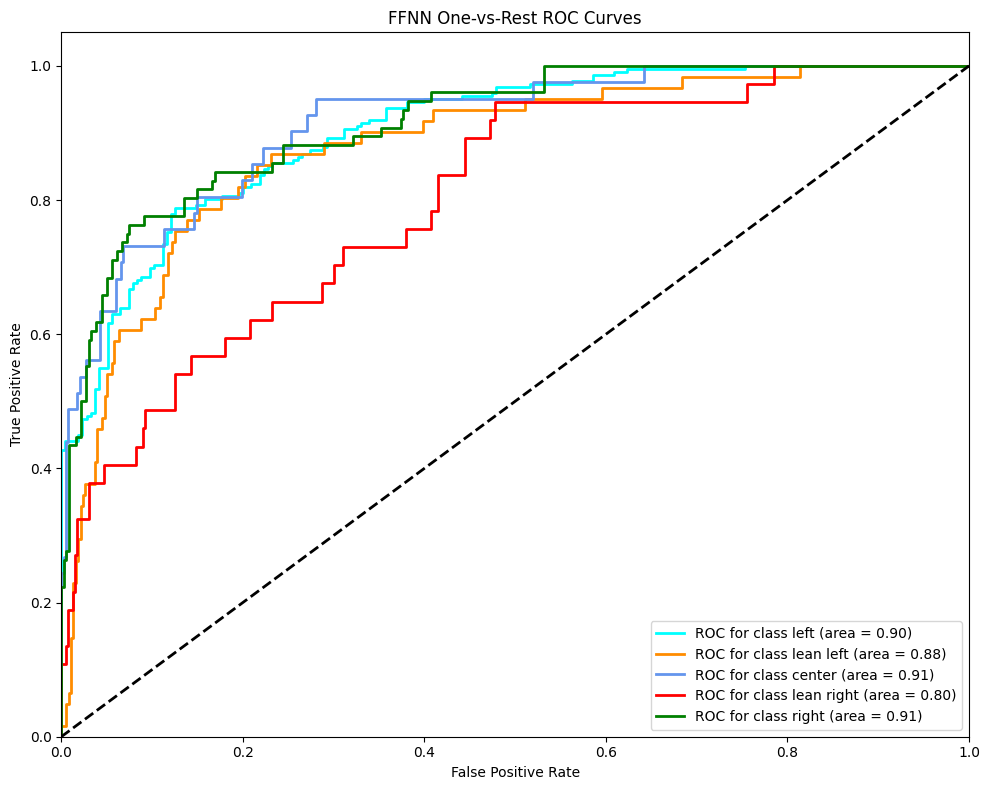

In [18]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=np.arange(output_dim))
probs = np.array(probs)
fpr = dict()
tpr = dict()
roc_auc = dict()

for label, idx in zip(label_order, label_indices):
    fpr[label], tpr[label], _ = roc_curve(y_test_bin[:, idx], probs[:, idx])
    roc_auc[label] = roc_auc_score(y_test_bin[:, idx], probs[:, idx])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for label, color in zip(label_order, colors):
    plt.plot(fpr[label], tpr[label], color=color, lw=2,
             label=f'ROC for class {label} (area = {roc_auc[label]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [19]:
macro_auc = roc_auc_score(y_test_bin, probs, average='weighted')
print(f"Macro-weighted ROC AUC: {macro_auc:.4f}")

Macro-weighted ROC AUC: 0.8951


ROC-AUC values are consistently strong across all classes:
- Left: 0.91  
- Lean Left: 0.88
- Center: 0.91  
- Lean Right: 0.80  
- Right: 0.91  

The macro-average ROC-AUC for the FFNN is 0.8943, indicating that the model performs consistently well across all classes, regardless of their frequency in the dataset. This suggests that the model has learned good decision boundaries for all classes, even if classification thresholds (affecting precision/recall) are not ideal for minority classes. 

## Final Conclusion

### Performance Metrics Evaluation Summary

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted DT | 65.84        | 0.5658         |
| Weighted DT   | 60.22        | 0.5209         |
| Tuned DT      | 57.53        | 0.5762         |
| FFNN (TF-IDF) | 72.54        | 0.6109         |

### Final Remarks

Overall, holding the vectorisation method of TD-IDF constant, the FFNN provides the best performance among all models so far, with high accuracy and robust AUC across classes. However, it still struggles on low-support categories with lean right only achieving precision of 0.500 and recall of 0.3243 with 37 support. This confirms that neural networks outperform decision trees in raw performance, but still benefit from further balancing techniques (e.g., class weighting or data augmentation).